In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text
import os

# Configuring visual defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Move to project root 
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

load_dotenv() 

## Database Connection
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine =create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    result = conn.execute(text("select count(*) from fraud_dw.fact_transactions"))
    count = result.scalar()
    print(f"Connected to database. Fact_transactions has {count:,} rows.")


Working directory: d:\Innomatics\Git_Uploads\Credit-card-risk-analytics
Connected to database. Fact_transactions has 590,540 rows.


In [3]:
# Find F1-optimal and cost-optimal thresholds together
query_full_sweep = """
WITH thresholds AS (
    SELECT generate_series(0, 60, 2) AS threshold
),
metrics AS (
    SELECT 
        th.threshold,
        COUNT(*) FILTER (WHERE s.risk_score >= th.threshold AND s.is_fraud)     AS tp,
        COUNT(*) FILTER (WHERE s.risk_score >= th.threshold AND NOT s.is_fraud) AS fp,
        SUM(s.transaction_amt) FILTER (WHERE s.risk_score >= th.threshold AND s.is_fraud)     AS fraud_caught,
        COUNT(*) FILTER (WHERE s.risk_score >= th.threshold AND NOT s.is_fraud) * 5           AS friction_cost,
        (SELECT COUNT(*) FILTER (WHERE is_fraud) FROM fraud_dw.v_scored_transactions)         AS total_fraud
    FROM thresholds th
    CROSS JOIN fraud_dw.v_scored_transactions s
    GROUP BY th.threshold
)
SELECT 
    threshold, tp, fp,
    ROUND(100.0 * tp::numeric / NULLIF(tp + fp, 0), 2)        AS precision_pct,
    ROUND(100.0 * tp::numeric / NULLIF(total_fraud, 0), 2)   AS recall_pct,
    ROUND(2.0 * (tp::numeric/NULLIF(tp+fp,0)) * (tp::numeric/NULLIF(total_fraud,0))
        / NULLIF((tp::numeric/NULLIF(tp+fp,0)) + (tp::numeric/NULLIF(total_fraud,0)),0) * 100, 2) AS f1_score,
    ROUND(fraud_caught - friction_cost, 2)                    AS net_benefit
FROM metrics
ORDER BY threshold;
"""

df = pd.read_sql(query_full_sweep, engine)

f1_best = df.loc[df['f1_score'].idxmax()]
cost_best = df.loc[df['net_benefit'].idxmax()]

print(f"F1-optimal threshold:   {int(f1_best['threshold'])}  "
      f"(F1={f1_best['f1_score']:.1f}%, recall={f1_best['recall_pct']:.1f}%)")
print(f"Cost-optimal threshold: {int(cost_best['threshold'])}  "
      f"(net=${cost_best['net_benefit']:,.0f}, recall={cost_best['recall_pct']:.1f}%)")

F1-optimal threshold:   10  (F1=20.4%, recall=21.9%)
Cost-optimal threshold: 10  (net=$245,722, recall=21.9%)


In [4]:
# Query the confusion matrix with threshold (18)
query_cm = """
WITH evaluation AS (
    SELECT 
        is_fraud,
        (risk_score >= 10) AS flagged
    FROM fraud_dw.v_scored_transactions
)
SELECT 
    COUNT(*) FILTER (WHERE flagged AND is_fraud)         AS true_positives,
    COUNT(*) FILTER (WHERE flagged AND NOT is_fraud)     AS false_positives,
    COUNT(*) FILTER (WHERE NOT flagged AND is_fraud)     AS false_negatives,
    COUNT(*) FILTER (WHERE NOT flagged AND NOT is_fraud) AS true_negatives
FROM evaluation;
"""

df_cm = pd.read_sql(query_cm, engine)
row = df_cm.iloc[0]

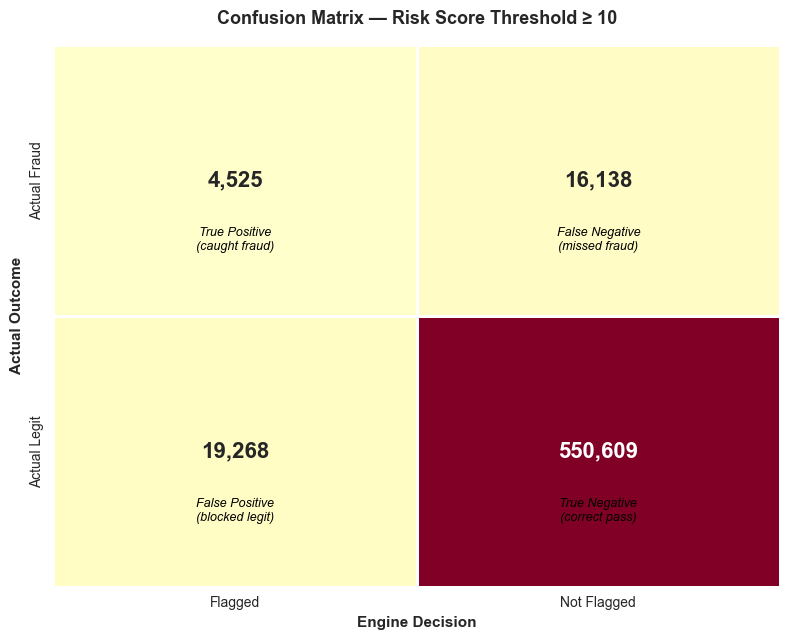

Precision: 19.02%  |  Recall: 21.90%


In [5]:

# Arrange into 2x2 matrix
# Rows = Actual (Fraud / Legit), Columns = Predicted (Flagged / Not Flagged)
cm = np.array([
    [row['true_positives'],  row['false_negatives']],   # Actual Fraud
    [row['false_positives'], row['true_negatives']]      # Actual Legit
])

fig, ax = plt.subplots(figsize=(8, 6.5))

sns.heatmap(
    cm,
    annot=True,
    fmt=',d',                      # comma-separated integers
    cmap='YlOrRd',
    cbar=False,
    linewidths=2,
    linecolor='white',
    xticklabels=['Flagged', 'Not Flagged'],
    yticklabels=['Actual Fraud', 'Actual Legit'],
    annot_kws={'size': 16, 'weight': 'bold'},
    ax=ax
)

# Add interpretive labels under each count
labels = [
    ['True Positive\n(caught fraud)', 'False Negative\n(missed fraud)'],
    ['False Positive\n(blocked legit)', 'True Negative\n(correct pass)']
]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.72, labels[i][j],
                ha='center', va='center', fontsize=9,
                color='black', style='italic')

ax.set_title('Confusion Matrix — Risk Score Threshold ≥ 10',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Engine Decision', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Outcome', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/phase5_confusion_matrix.png', bbox_inches='tight')
plt.show()

# Print the derived metrics for the narrative
tp, fn = row['true_positives'], row['false_negatives']
fp, tn = row['false_positives'], row['true_negatives']
precision = 100 * tp / (tp + fp)
recall = 100 * tp / (tp + fn)
print(f"Precision: {precision:.2f}%  |  Recall: {recall:.2f}%")

In [6]:
query_cb = """
WITH evaluation AS (
    SELECT 
        is_fraud,
        transaction_amt,
        (risk_score >= 10) AS flagged
    FROM fraud_dw.v_scored_transactions
)
SELECT 
    ROUND(SUM(transaction_amt) FILTER (WHERE flagged AND is_fraud), 2)     AS fraud_caught,
    ROUND(SUM(transaction_amt) FILTER (WHERE NOT flagged AND is_fraud), 2) AS fraud_missed,
    (COUNT(*) FILTER (WHERE flagged AND NOT is_fraud) * 5)                 AS friction_cost,
    ROUND(SUM(transaction_amt) FILTER (WHERE flagged AND is_fraud) 
          - COUNT(*) FILTER (WHERE flagged AND NOT is_fraud) * 5, 2)       AS net_benefit
FROM evaluation;
"""

df_cb = pd.read_sql(query_cb, engine)
cb = df_cb.iloc[0]

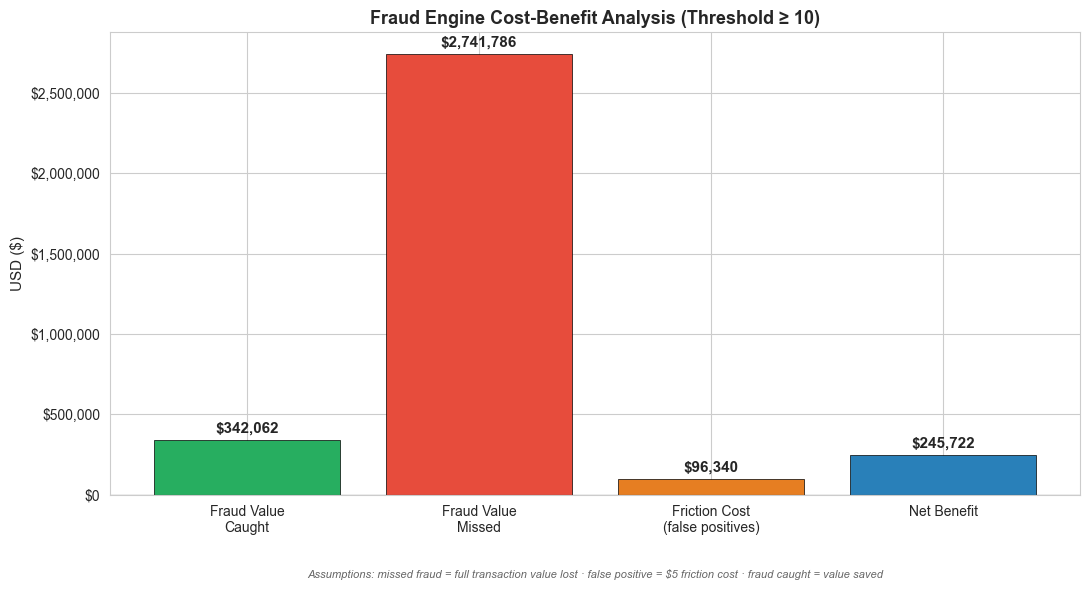

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

categories = ['Fraud Value\nCaught', 'Fraud Value\nMissed', 'Friction Cost\n(false positives)', 'Net Benefit']
values = [cb['fraud_caught'], cb['fraud_missed'], cb['friction_cost'], cb['net_benefit']]

# Green for gains, red for losses/costs, blue for the net
colors = ['#27ae60', '#e74c3c', '#e67e22', '#2980b9']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=0.5)

# Dollar labels on each bar
for bar, val in zip(bars, values):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    offset = max(values) * 0.01
    ax.text(bar.get_x() + bar.get_width()/2, 
            height + (offset if height >= 0 else -offset),
            f'${val:,.0f}', ha='center', va=va, 
            fontweight='bold', fontsize=11)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('USD ($)', fontsize=11)
ax.set_title('Fraud Engine Cost-Benefit Analysis (Threshold ≥ 10)',
             fontsize=13, fontweight='bold')

# Format y-axis with comma separators
ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x):,}'))

# Footnote stating assumptions
ax.text(0.5, -0.18, 
        'Assumptions: missed fraud = full transaction value lost · '
        'false positive = $5 friction cost · fraud caught = value saved',
        transform=ax.transAxes, ha='center', fontsize=8, 
        style='italic', color='#666')

plt.tight_layout()
plt.savefig('visuals/phase5_cost_benefit.png', bbox_inches='tight')
plt.show()

In [8]:
query = """
with thresholds as (
select generate_series(0,60,2) as threshold
),
metrics as (
	select t.threshold,
	count(*) filter (where s.risk_score >= threshold and s.is_fraud) 	as tp,
	count(*) filter (where s.risk_score >= threshold and not s.is_fraud) 	as fp,
	count(*) filter (where is_fraud)										as tot_fraud
from thresholds t
	cross join fraud_dw.v_scored_transactions s
group by t.threshold,
	(select count(*) filter (where is_fraud) from fraud_dw.v_scored_transactions)		
)
select 
	threshold,
	tp,
	fp,
	round(100.0 * tp::numeric / nullif(tp + fp,0),2) as precesion_pct,
	round(100.0 * tp::numeric / nullif(tot_fraud,0),2) as recall_pct,
	-- F1 score
	round(2.0 * (tp::numeric/nullif(tp+fp,0)) * (tp::numeric / NULLIF(tot_fraud, 0))
		/NULLIF((tp::numeric / NULLIF(tp + fp, 0)) + (tp::numeric / NULLIF(tot_fraud, 0)), 0) * 100, 2) as f1_score
from metrics
order by threshold;
"""

df = pd.read_sql(query,engine)
df.head(7)

,threshold,tp,fp,precesion_pct,recall_pct,f1_score
0,0,20663,569877,3.50,100.00,6.76
1,2,6327,39299,13.87,30.62,19.09
2,4,6327,39299,13.87,30.62,19.09
3,6,6327,39299,13.87,30.62,19.09
4,8,6327,39299,13.87,30.62,19.09
5,10,4525,19268,19.02,21.90,20.36
6,12,4525,19268,19.02,21.90,20.36


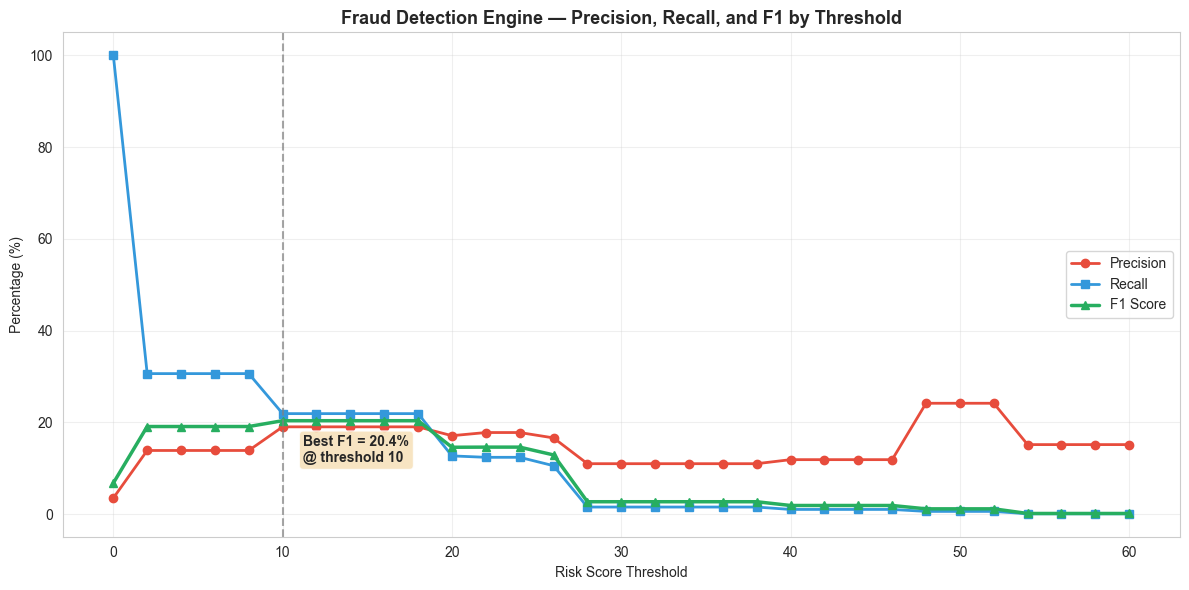

In [4]:
# Threshold sweep results → df
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df['threshold'], df['precesion_pct'], 
         color='#e74c3c', marker='o', linewidth=2, label='Precision')
ax1.plot(df['threshold'], df['recall_pct'], 
         color='#3498db', marker='s', linewidth=2, label='Recall')
ax1.plot(df['threshold'], df['f1_score'], 
         color='#27ae60', marker='^', linewidth=2.5, label='F1 Score')

# Mark the best F1 threshold
best = df.loc[df['f1_score'].idxmax()]
ax1.axvline(best['threshold'], color='gray', linestyle='--', alpha=0.7)
ax1.annotate(f"Best F1 = {best['f1_score']:.1f}%\n@ threshold {int(best['threshold'])}",
             (best['threshold'], best['f1_score']),
             textcoords="offset points", xytext=(15, -30),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))

ax1.set_xlabel('Risk Score Threshold')
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Fraud Detection Engine — Precision, Recall, and F1 by Threshold',
              fontsize=13, fontweight='bold')
ax1.legend(loc='center right')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visuals/phase5_pr_curve.png', bbox_inches='tight')
plt.show()

## Conclusion 

## Phase 5 Summary — The Detection Engine

The confusion matrix shows the engine catches **4,525 of 20,663** fraud cases 
(recall ~21.9%) while flagging **19,268** legitimate transactions as false positives. 

The cost-benefit view translates this into dollars: the engine saves **$342,062** 
in caught fraud against only **$96,340** in friction cost, for a net benefit of 
**$245,722** — even under the conservative assumption that every false positive 
costs $5 in customer support and friction.

The missed fraud (**$2,741,786**) represents the engine's blind spot — primarily 
transactions that fall outside the free_webmail / Card-Not-Present segments that 
drive most detection. A production system would add complementary rules to close 
this gap.

**Performance at optimal threshold:**
- Precision: 19.02% (of flagged transactions, 19.01% were truly fraud)
- Recall: 21.90% (caught 21.89% of all fraud)
- F1: 20.36%

**Business impact:**
- Fraud value caught: $342,062
- Net benefit after friction costs: $245,722

**Key design choice:** Rules were derived from Phase 4's measured segments rather than 
assumed, so each rule's contribution was weighted by its known precision. The two dominant 
free_webmail segments (66% of all fraud) drove most of the recall.

**Limitation:** This is a static rule engine. A production system would refresh rule 
weights as fraud patterns evolve, and would benefit from the per-card velocity signal 
that this anonymized dataset couldn't provide (see Phase 3).

-----------------

## Engine Limitations :
The engine achieves 21.9% recall at 20%+ precision using only categorical features. This reflects a fundamental constraint: the dataset's anonymization removes the per-card velocity signal (Phase 3) that drives most production fraud systems, leaving only weakly-separating categorical attributes. The cost-benefit analysis nonetheless shows a positive net benefit of $245,722, because the asymmetric cost structure (missed fraud = full value, false positive = $5 review cost) favors aggressive flagging for human review. In production, this rule layer would serve as a first-pass filter feeding a review queue, complemented by velocity features and an ML model trained on richer signals.

## Test case :

Tested but rejected — broad coverage rules. I added two high-volume, low-precision rules (Web Purchase + free_webmail; broad CNP + free_webmail) to lift recall. They raised recall from 21.6% to 30.6%, but net benefit fell from $246K to $200K — the ~20,000 additional false positives cost more in review friction than the extra caught fraud was worth. The rules were removed. This confirms the engine's profitable detection ceiling is reached by the four narrow high-precision rules; broadening the net adds cost without value under the given cost structure.